# Biomedical Image-Analysis Pipeline — Nuclei Segmentation & Description
### (Google Colab version)

**Student ID:** 24142732
**Modality / dataset:** Synthetic DAPI-like fluorescence-microscopy nuclei (`Assingnment-3-dataset`), 256x256 RGB, CC0.

Pipeline: raw image → segmentation → quantitative region features → structured JSON record → short narrative.

All LLMs run **locally inside this Colab VM via Ollama** (`llama3.2-vision` for the vision step, `llama3.2` for the
text step). Outputs are for **educational use only** — none of these models are cleared for clinical use.

> **Run order matters here:** run the "Colab setup" section first (dataset + packages + Ollama), wait for Ollama
> models to finish pulling, THEN run the task cells top to bottom. Use **Runtime → Change runtime type → GPU**
> (T4) before you start, so U-Net training and Ollama both go faster.


## Colab setup — run this section first

In [1]:
# 1. Clone the dataset repo and unzip it
!git clone -q https://github.com/Nickolay-K/Assingnment-3-dataset.git
!unzip -oq Assingnment-3-dataset/nuclei_dataset.zip -d Assingnment-3-dataset/unzipped
!cp -r Assingnment-3-dataset/unzipped/nuclei_dataset ./nuclei_dataset
!ls nuclei_dataset


dataset_summary.json  metadata.csv  test	    train
make_dataset.py       README.md     test_corrupted  val


In [2]:
# 2. Install Python packages (torch/torchvision/skimage are already in Colab; ollama client is not)
!pip install -q ollama


In [3]:
!apt-get install zstd -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 67 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (2,605 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 122492 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


In [4]:
# 3. Install Ollama itself (the local LLM server) inside this Colab VM
!curl -fsSL https://ollama.com/install.sh | sh


>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [5]:
# 4. Start the Ollama server in the background (Colab has no separate terminal, so we launch it
#    as a background process and give it a few seconds to come up)
import subprocess, time
ollama_process = subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(5)
print("Ollama server starting (pid:", ollama_process.pid, ")")


Ollama server starting (pid: 2085 )


In [6]:
# 5. Pull the models. llama3.2-vision is ~8GB and will take a few minutes on Colab's connection.
#    Also pull llava as a fallback vision model — some Ollama builds fail to load llama3.2-vision
#    with "unknown model architecture: mllama"; if that happens, task1_vlm.py automatically
#    switches to llava so the notebook doesn't get stuck on this step.
!ollama pull llama3.2-vision
!ollama pull llava
!ollama pull llama3.2
!ollama list





NAME                      ID              SIZE      MODIFIED               
llama3.2:latest           a80c4f17acd5    2.0 GB    Less than a second ago    
llava:latest              8dd30f6b0cb1    4.7 GB    21 seconds ago            
llama3.2-vision:latest    6f2f9757ae97    7.8 GB    About a minute ago        


If `ollama list` above shows `llama3.2-vision`, `llava`, and `llama3.2`, setup is done — run the task
cells below. If a task cell later says it "could not reach Ollama", re-run the two cells above (server
sometimes needs a second start after Colab's first apt/curl install).

**If you see an error like `unknown model architecture: 'mllama'`** when Task 1 runs: this is a known
Ollama-version compatibility issue with `llama3.2-vision` on some Colab installs. `task1_vlm.py` already
falls back to `llava` automatically when this happens — just re-run the Task 1 VLM cell and check the
printed `model_used` value (report which model actually produced your output). If you want to force a
clean reinstall instead, run the optional troubleshooting cell below.


In [7]:
# OPTIONAL troubleshooting cell — only run this if llama3.2-vision keeps failing to load
# even through the llava fallback. This does a clean Ollama reinstall + re-pull.
# !ollama rm llama3.2-vision
# import subprocess, time
# ollama_process.kill()
# time.sleep(2)
# !curl -fsSL https://ollama.com/install.sh | sh
# ollama_process = subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
# time.sleep(5)
# !ollama pull llama3.2-vision
# !ollama --version


In [8]:
import warnings
warnings.filterwarnings("ignore")
import os
print("Working directory:", os.getcwd())
assert os.path.isdir("nuclei_dataset"), "Dataset clone/unzip above did not complete — re-run the setup cells."


Working directory: /content


## Task 1 — Data preparation, EDA, and multimodal LLM description

Steps: convert images to grayscale, resize to 256x256, produce a sample grid and an intensity histogram,
then send a representative image to `llama3.2-vision` via Ollama with two prompts:
- a **naive prompt** (no anchoring, no schema)
- an **engineered structured prompt** (anchored as descriptive not diagnostic, forces JSON, permits "uncertain")

and run the structured prompt twice to demonstrate that outputs are not identical between runs.


In [9]:
import os, glob, json
import numpy as np
from PIL import Image
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

DATA_DIR = "nuclei_dataset"
OUT = "outputs"
os.makedirs(OUT, exist_ok=True)

def load_gray_resized(path, size=(256,256)):
    im = Image.open(path).convert("L").resize(size, Image.BILINEAR)
    return np.array(im)

train_imgs = sorted(glob.glob(f"{DATA_DIR}/train/images/*.png"))
print("train images:", len(train_imgs))

# sample grid of 6 images (grayscale, resized)
fig, axes = plt.subplots(2, 3, figsize=(9,6))
sample_paths = train_imgs[:6]
for ax, p in zip(axes.ravel(), sample_paths):
    g = load_gray_resized(p)
    ax.imshow(g, cmap="gray")
    ax.set_title(os.path.basename(p), fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{OUT}/task1_sample_grid.png", dpi=130)
plt.close()

# intensity histogram over a batch of grayscale images
all_pixels = []
for p in train_imgs[:20]:
    g = load_gray_resized(p)
    all_pixels.append(g.ravel())
all_pixels = np.concatenate(all_pixels)

plt.figure(figsize=(6,4))
plt.hist(all_pixels, bins=50, color="slateblue")
plt.title("Grayscale intensity histogram (20 train images, 256x256)")
plt.xlabel("Pixel intensity (0-255)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{OUT}/task1_intensity_hist.png", dpi=130)
plt.close()

print("mean:", all_pixels.mean(), "std:", all_pixels.std())
print("Saved sample grid + histogram to outputs/")


train images: 80
mean: 9.141799163818359 std: 18.148483287590803
Saved sample grid + histogram to outputs/


### Display the EDA outputs

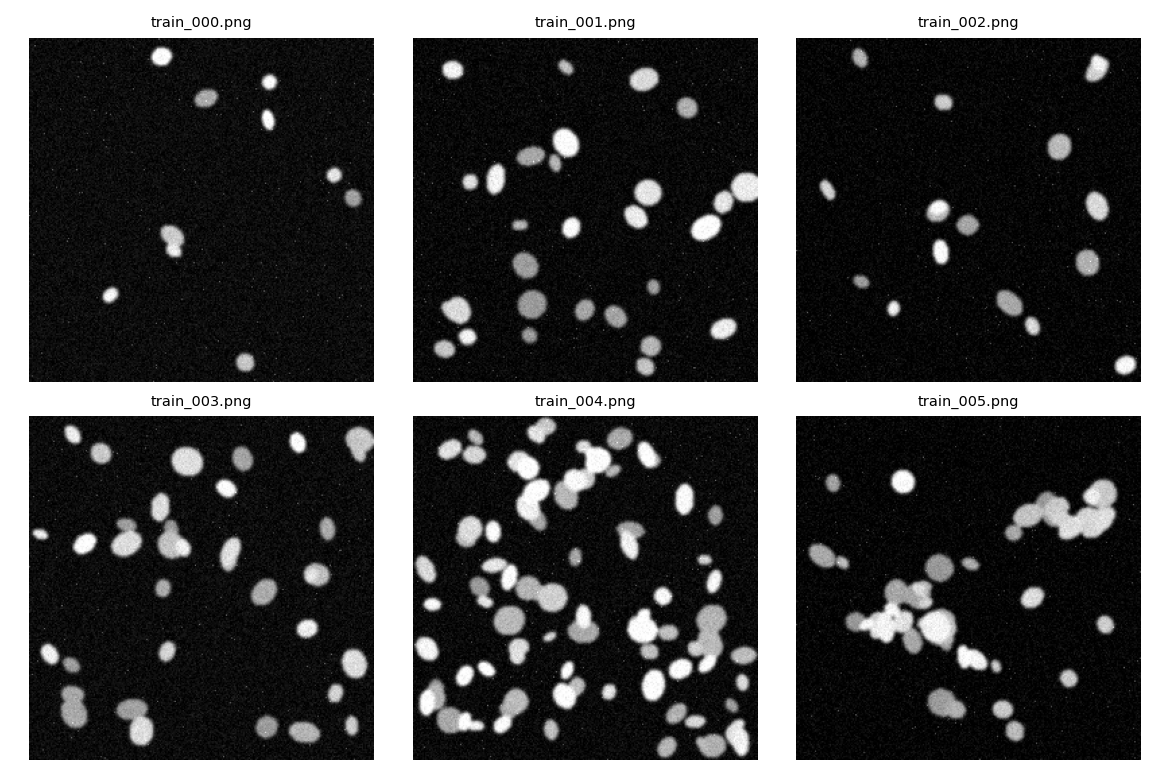

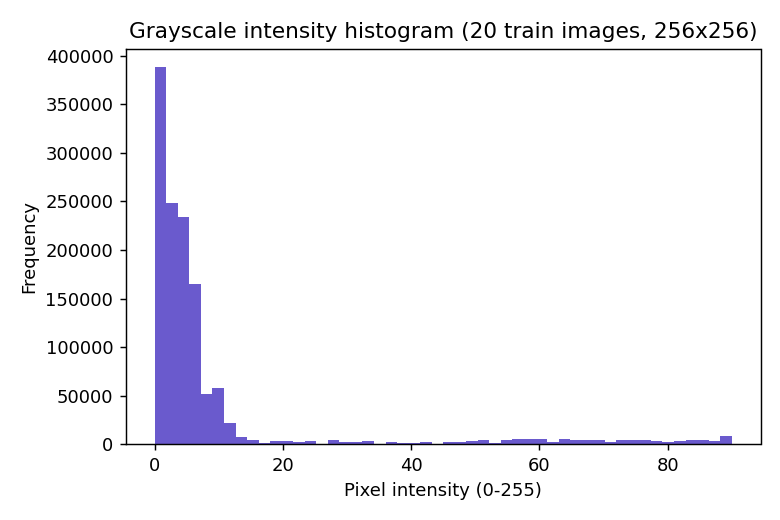

In [10]:
from IPython.display import Image as IPImage, display
display(IPImage(filename="outputs/task1_sample_grid.png"))
display(IPImage(filename="outputs/task1_intensity_hist.png"))


### VLM prompt comparison (naive vs. structured, run twice)

**The optimised structured prompt (must appear in the report):**

```
You are an image-description assistant supporting a research pipeline.
You are NOT a diagnostic tool and must not provide clinical diagnoses, disease names,
or treatment suggestions. Only describe what is visually present in the image.

Describe this fluorescence microscopy image and respond with ONLY a single JSON object,
no other text, matching exactly this schema:

{
  "modality": string,          // e.g. "fluorescence microscopy" or "uncertain"
  "tissue_type": string,       // best guess at tissue/cell type, or "uncertain"
  "notable_features": string,  // 1-2 sentences on shape, distribution, density of visible objects
  "image_quality": string      // one of: "good", "noisy", "low_contrast", "uncertain"
}

If you are not confident about a field, use the string "uncertain" for that field rather
than guessing. Do not include any text before or after the JSON object.
```


In [11]:
"""
Task 1 (part 2): send a representative image to a local multimodal model
via Ollama, comparing a NAIVE prompt against an ENGINEERED structured prompt.
Run this file directly on your machine / Colab, where Ollama is already
installed and running (`ollama serve`), after pulling the model:

    ollama pull llama3.2-vision

If llama3.2-vision fails to load (some Ollama builds error with
"unknown model architecture: 'mllama'"), this script automatically falls
back to `llava`, a more broadly-compatible vision model, and prints a note
if it does. Record the notebook's printed MODEL_USED value in your report.

If Ollama is not reachable at all, this script prints a clear message instead
of crashing, so the rest of the notebook can still run end-to-end.
"""
import os, json, glob
import ollama

PRIMARY_MODEL = "llama3.2-vision"
FALLBACK_MODEL = "llava"
DATA_DIR = "nuclei_dataset"
OUT = "outputs"

REPRESENTATIVE_IMAGE = sorted(glob.glob(f"{DATA_DIR}/train/images/*.png"))[4]  # train_004: dense regime

# --- Naive prompt: no anchoring, no output format, invites diagnostic overreach ---
NAIVE_PROMPT = "What do you see in this microscopy image?"

# --- Engineered structured prompt ---
# Design choices (discuss these in the report):
#  1. Explicitly anchors the model as a DESCRIPTIVE assistant, not a diagnostic one,
#     to reduce the chance it invents a clinical diagnosis it has no basis for.
#  2. Forces a strict JSON schema so downstream code can parse the output reliably
#     instead of scraping free text (this is what "auditable" means in this assignment).
#  3. Explicitly permits "uncertain" as a valid value for any field, which gives the
#     model a documented way to abstain instead of guessing/hallucinating.
#  4. Asks it to ground notable_features only in what is visually present.
STRUCTURED_PROMPT = """You are an image-description assistant supporting a research pipeline.
You are NOT a diagnostic tool and must not provide clinical diagnoses, disease names,
or treatment suggestions. Only describe what is visually present in the image.

Describe this fluorescence microscopy image and respond with ONLY a single JSON object,
no other text, matching exactly this schema:

{
  "modality": string,          // e.g. "fluorescence microscopy" or "uncertain"
  "tissue_type": string,       // best guess at tissue/cell type, or "uncertain"
  "notable_features": string,  // 1-2 sentences on shape, distribution, density of visible objects
  "image_quality": string      // one of: "good", "noisy", "low_contrast", "uncertain"
}

If you are not confident about a field, use the string "uncertain" for that field rather
than guessing. Do not include any text before or after the JSON object."""


def call_vlm(image_path, prompt, model):
    response = ollama.chat(
        model=model,
        messages=[{"role": "user", "content": prompt, "images": [image_path]}],
    )
    return response["message"]["content"]


def call_vlm_with_fallback(image_path, prompt):
    """Try the primary vision model; if it fails to load (e.g. 'unknown model
    architecture: mllama' on some Ollama builds), fall back automatically."""
    try:
        return call_vlm(image_path, prompt, PRIMARY_MODEL), PRIMARY_MODEL
    except Exception as e:
        print(f"[warning] {PRIMARY_MODEL} failed ({e}); trying fallback model {FALLBACK_MODEL}...")
        return call_vlm(image_path, prompt, FALLBACK_MODEL), FALLBACK_MODEL


def try_parse_json(text):
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        # model sometimes wraps JSON in ```json fences despite instructions
        cleaned = text.strip().strip("`")
        cleaned = cleaned.replace("json\n", "", 1) if cleaned.startswith("json\n") else cleaned
        try:
            return json.loads(cleaned)
        except json.JSONDecodeError:
            return None


if __name__ == "__main__":
    os.makedirs(OUT, exist_ok=True)
    print(f"Representative image: {REPRESENTATIVE_IMAGE}\n")

    try:
        print("=== NAIVE PROMPT ===")
        naive_out, model_used = call_vlm_with_fallback(REPRESENTATIVE_IMAGE, NAIVE_PROMPT)
        print(f"(model used: {model_used})")
        print(naive_out)

        print("\n=== STRUCTURED PROMPT (run 1) ===")
        structured_out_1, model_used = call_vlm_with_fallback(REPRESENTATIVE_IMAGE, STRUCTURED_PROMPT)
        print(f"(model used: {model_used})")
        print(structured_out_1)

        print("\n=== STRUCTURED PROMPT (run 2, same image+prompt, to show non-determinism) ===")
        structured_out_2, model_used = call_vlm_with_fallback(REPRESENTATIVE_IMAGE, STRUCTURED_PROMPT)
        print(f"(model used: {model_used})")
        print(structured_out_2)

        parsed_1 = try_parse_json(structured_out_1)
        parsed_2 = try_parse_json(structured_out_2)

        results = {
            "image": REPRESENTATIVE_IMAGE,
            "model_used": model_used,
            "naive_prompt": NAIVE_PROMPT,
            "naive_output": naive_out,
            "structured_prompt": STRUCTURED_PROMPT,
            "structured_output_run1": structured_out_1,
            "structured_output_run1_valid_json": parsed_1 is not None,
            "structured_output_run2": structured_out_2,
            "structured_output_run2_valid_json": parsed_2 is not None,
            "runs_identical": structured_out_1.strip() == structured_out_2.strip(),
        }
        with open(f"{OUT}/task1_vlm_outputs.json", "w") as f:
            json.dump(results, f, indent=2)
        print(f"\nModel used for this run: {model_used}")
        print(f"Runs identical: {results['runs_identical']}")
        print("Saved outputs/task1_vlm_outputs.json")

    except Exception as e:
        print(f"Could not reach Ollama, or neither {PRIMARY_MODEL} nor {FALLBACK_MODEL} could be loaded.")
        print("Make sure `ollama serve` is running and you have run:")
        print(f"    ollama pull {PRIMARY_MODEL}")
        print(f"    ollama pull {FALLBACK_MODEL}")
        print(f"Underlying error: {e}")



Representative image: nuclei_dataset/train/images/train_004.png

=== NAIVE PROMPT ===
[warning] llama3.2-vision failed (llama-server process has terminated: exit status 1: error loading model: unknown model architecture: 'mllama'
error loading model: unknown model architecture: 'mllama' (status code: 500)); trying fallback model llava...
(model used: llava)
 The image appears to be a microscopy photograph of cells, as evidenced by the regular, organized appearance of the circular objects. These objects could be cells with nuclei, as the darker areas resemble nuclei, which are typical in eukaryotic cells. The blue coloration suggests that these cells have been stained with a fluorescent dye, likely in the context of a microscopy technique such as immunostaining or fluorescence in situ hybridization (FISH), which are commonly used in cytology to visualize specific cellular components. The blue coloration contrasts with the dark background, which helps to highlight the cells and their int

## Task 2 — Classical features and numbers-first LLM interpretation

Otsu thresholding + morphological opening/closing → connected-component labelling →
`regionprops_table` (area, eccentricity, solidity, mean intensity, perimeter, axis lengths) →
a numbers-only natural-language summary → sent to a **text-only** local LLM (the model never sees the image).


In [12]:
import os, glob
import numpy as np
import pandas as pd
from PIL import Image
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, binary_opening, binary_closing, disk
from skimage.measure import label, regionprops_table
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

DATA_DIR = "nuclei_dataset"
OUT = "outputs"

def load_gray(path, size=(256,256)):
    im = Image.open(path).convert("L").resize(size, Image.BILINEAR)
    return np.array(im)

def otsu_segment(gray):
    """Otsu threshold + morphological cleanup -> labeled component image."""
    gray_f = gray.astype(float) / 255.0
    thresh = threshold_otsu(gray_f)
    binary = gray_f > thresh
    # morphological cleanup: opening removes speckle noise, closing fills small gaps
    binary = binary_opening(binary, disk(1))
    binary = binary_closing(binary, disk(1))
    binary = remove_small_objects(binary, min_size=8)
    labeled = label(binary)
    return labeled, binary, thresh

def feature_table(labeled, intensity_img):
    props = regionprops_table(
        labeled, intensity_image=intensity_img,
        properties=("label", "area", "eccentricity", "solidity",
                    "mean_intensity", "perimeter", "major_axis_length", "minor_axis_length")
    )
    return pd.DataFrame(props)

def table_to_summary(df, image_id):
    """Numbers-only natural language summary (no image is passed to the LLM)."""
    if len(df) == 0:
        return f"Image {image_id}: Otsu segmentation found 0 objects after cleanup."
    n = len(df)
    mean_area = df["area"].mean()
    med_area = df["area"].median()
    mean_ecc = df["eccentricity"].mean()
    mean_sol = df["solidity"].mean()
    mean_int = df["mean_intensity"].mean()
    summary = (
        f"Image {image_id}: Otsu thresholding + morphological cleanup detected {n} connected "
        f"components. Mean object area is {mean_area:.1f} px^2 (median {med_area:.1f} px^2). "
        f"Mean eccentricity is {mean_ecc:.2f} (0=circle, 1=line), mean solidity is {mean_sol:.2f} "
        f"(1.0=fully convex, no dents). Mean intensity inside objects is {mean_int:.2f} (0-1 scale)."
    )
    return summary

if True:
    test_imgs = sorted(glob.glob(f"{DATA_DIR}/test/images/*.png"))
    rows = []
    example_summary = None
    for p in test_imgs:
        image_id = os.path.splitext(os.path.basename(p))[0]
        gray = load_gray(p)
        labeled, binary, thresh = otsu_segment(gray)
        df = feature_table(labeled, gray.astype(float)/255.0)
        summary = table_to_summary(df, image_id)
        if image_id == "test_004":
            example_summary = summary
            example_df = df.copy()
        rows.append({"image_id": image_id, "n_objects_otsu": len(df),
                     "mean_area": df["area"].mean() if len(df) else 0,
                     "otsu_threshold": thresh})
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(f"{OUT}/task2_otsu_summary_per_image.csv", index=False)
    print(summary_df)
    print("\nExample numbers-only summary (test_004), this text is what gets sent to the LLM:\n")
    print(example_summary)
    example_df.to_csv(f"{OUT}/task2_example_feature_table_test_004.csv", index=False)

    # visual check: original / binary mask / labeled overlay for one image
    p = f"{DATA_DIR}/test/images/test_004.png"
    gray = load_gray(p)
    labeled, binary, thresh = otsu_segment(gray)
    fig, axes = plt.subplots(1, 3, figsize=(10,4))
    axes[0].imshow(gray, cmap="gray"); axes[0].set_title("Grayscale input"); axes[0].axis("off")
    axes[1].imshow(binary, cmap="gray"); axes[1].set_title(f"Otsu binary (t={thresh:.3f})"); axes[1].axis("off")
    axes[2].imshow(labeled, cmap="nipy_spectral"); axes[2].set_title(f"Labeled ({labeled.max()} objects)"); axes[2].axis("off")
    plt.tight_layout()
    plt.savefig(f"{OUT}/task2_otsu_pipeline_test_004.png", dpi=130)
    plt.close()
    print("\nSaved outputs/task2_otsu_pipeline_test_004.png")


    image_id  n_objects_otsu   mean_area  otsu_threshold
0   test_000               8  194.750000        0.113741
1   test_001              14  202.071429        0.133042
2   test_002              24  241.208333        0.128906
3   test_003              19  203.157895        0.141314
4   test_004              41  344.000000        0.137178
5   test_005              14  463.071429        0.137178
6   test_006               8  196.625000        0.156480
7   test_007              23  207.043478        0.133042
8   test_008              22  250.136364        0.137178
9   test_009              21  180.000000        0.133042
10  test_010              33  395.121212        0.145450
11  test_011              17  215.647059        0.141314

Example numbers-only summary (test_004), this text is what gets sent to the LLM:

Image test_004: Otsu thresholding + morphological cleanup detected 41 connected components. Mean object area is 344.0 px^2 (median 244.0 px^2). Mean eccentricity is 0.65 (0=cir

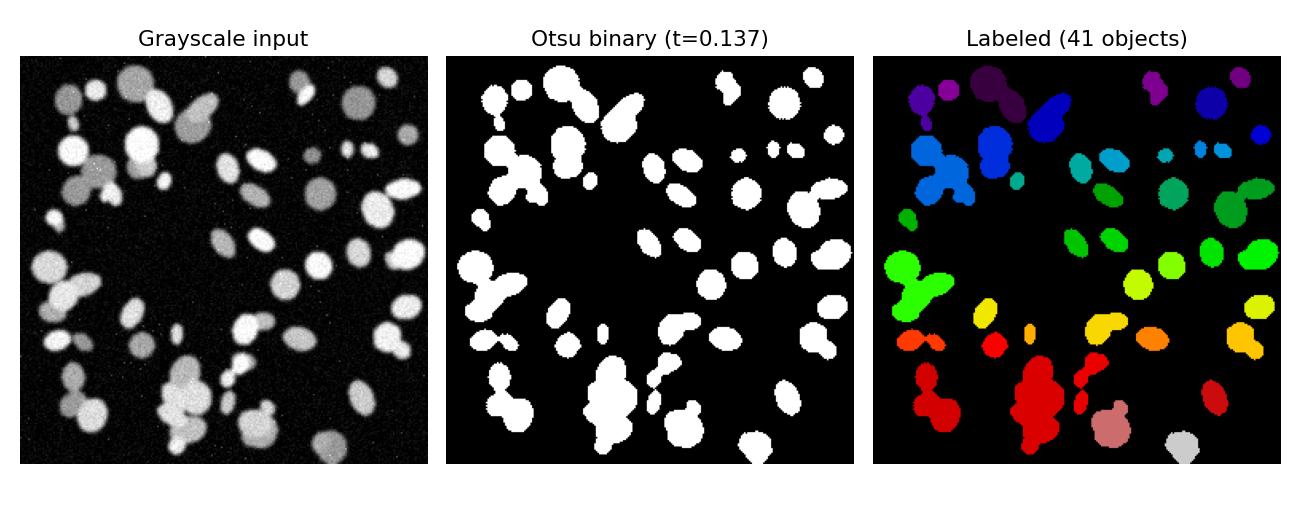

In [13]:
from IPython.display import Image as IPImage, display
display(IPImage(filename="outputs/task2_otsu_pipeline_test_004.png"))


### Numbers-first LLM interpretation (text model, image never shown to the model)

In [14]:
"""
Task 2 (part 2): pass the numbers-only summary (from task2_classical.py) to a
local text LLM and request a one-paragraph description + structured JSON.
The model NEVER sees the image, only the regionprops-derived summary text.
Run this on your machine with Ollama running.
"""
import json
import ollama
# from task2_classical import load_gray, otsu_segment, feature_table, table_to_summary  (already defined above in this notebook)

MODEL = "llama3.2"  # text-only model; swap for whatever you have pulled
DATA_DIR = "nuclei_dataset"
OUT = "outputs"

LLM_PROMPT_TEMPLATE = """You are given ONLY numeric measurements extracted by classical image
processing (Otsu thresholding + connected-component analysis) from a fluorescence microscopy
image. You have NOT seen the image itself. Do not invent visual details you were not given.

Measurements:
{summary}

Write:
1. One paragraph (2-4 sentences) describing what this object population likely looks like,
   grounded ONLY in the numbers above.
2. Then a JSON object on its own, matching exactly this schema:
{{
  "n_objects": integer,
  "density_class": string,   // one of "sparse", "normal", "dense", "clustered", "uncertain"
  "shape_regularity": string, // one of "regular", "irregular", "mixed", "uncertain"
  "quality_flag": string      // one of "reliable", "check_thresholding", "uncertain"
}}

Respond with the paragraph first, then a line "---JSON---", then the JSON object only."""


def call_text_llm(summary_text):
    prompt = LLM_PROMPT_TEMPLATE.format(summary=summary_text)
    response = ollama.chat(model=MODEL, messages=[{"role": "user", "content": prompt}])
    return response["message"]["content"]


if True:
    image_id = "test_004"
    gray = load_gray(f"{DATA_DIR}/test/images/{image_id}.png")
    labeled, binary, thresh = otsu_segment(gray)
    df = feature_table(labeled, gray.astype(float) / 255.0)
    summary = table_to_summary(df, image_id)
    print("Numbers-only summary sent to LLM:\n", summary, "\n")

    try:
        out = call_text_llm(summary)
        print("=== LLM response ===")
        print(out)
        with open(f"{OUT}/task2_llm_output_{image_id}.txt", "w") as f:
            f.write(f"SUMMARY SENT TO LLM:\n{summary}\n\nLLM RESPONSE:\n{out}")
        print(f"\nSaved outputs/task2_llm_output_{image_id}.txt")
    except Exception as e:
        print("Could not reach Ollama on this machine. Make sure `ollama serve` is running")
        print("and you have pulled a text model, e.g.: ollama pull llama3.2")
        print(f"Underlying error: {e}")


Numbers-only summary sent to LLM:
 Image test_004: Otsu thresholding + morphological cleanup detected 41 connected components. Mean object area is 344.0 px^2 (median 244.0 px^2). Mean eccentricity is 0.65 (0=circle, 1=line), mean solidity is 0.92 (1.0=fully convex, no dents). Mean intensity inside objects is 0.26 (0-1 scale). 

=== LLM response ===
Based on the provided measurements, the object population is likely composed of small, uniform, and convex objects. The mean object area of 344.0 px^2 and median of 244.0 px^2 suggest a relatively small size, while the mean solidity of 0.92 indicates that the objects are not significantly dent-free. The low mean intensity inside objects (0.26) suggests that the objects are dark in color.

---JSON---
{
  "n_objects": 41,
  "density_class": "dense",
  "shape_regularity": "regular",
  "quality_flag": "reliable"
}

Saved outputs/task2_llm_output_test_004.txt


## Task 3 — U-Net segmentation

A compact 3-level U-Net (PyTorch, ~16 base channels) trained from scratch on the 80-image train split,
loss = BCE + Dice, evaluated on the 20-image held-out validation split with mean Dice and IoU.
On Colab's T4 GPU you can safely bump `img_size` back up to 256 (edit the `train(...)` call below) — CPU
fallback at 128x128 is only needed if you're not using a GPU runtime.


In [15]:
import os, glob, time
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

torch.manual_seed(24142732)  # student ID as seed, reproducible
DATA_DIR = "nuclei_dataset"
OUT = "outputs"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ---------------- Dataset ----------------
class NucleiDataset(Dataset):
    def __init__(self, split, size=128):
        # 128x128 keeps CPU training tractable while remaining a fair comparison;
        # bump back to 256 if training on GPU.
        self.img_paths = sorted(glob.glob(f"{DATA_DIR}/{split}/images/*.png"))
        self.mask_paths = sorted(glob.glob(f"{DATA_DIR}/{split}/masks/*.png"))
        assert len(self.img_paths) == len(self.mask_paths)
        self.size = size

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("L").resize((self.size, self.size), Image.BILINEAR)
        mask = Image.open(self.mask_paths[idx]).convert("L").resize((self.size, self.size), Image.NEAREST)
        img = np.array(img, dtype=np.float32) / 255.0
        mask = (np.array(mask, dtype=np.float32) > 127).astype(np.float32)
        img = torch.from_numpy(img).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)
        return img, mask, os.path.basename(self.img_paths[idx])

# ---------------- Small U-Net ----------------
def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
    )

class SmallUNet(nn.Module):
    """Compact 3-level U-Net, sized for a small biomedical dataset trained on CPU."""
    def __init__(self, base=16):
        super().__init__()
        self.enc1 = conv_block(1, base)
        self.enc2 = conv_block(base, base*2)
        self.enc3 = conv_block(base*2, base*4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = conv_block(base*4, base*8)
        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = conv_block(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = conv_block(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = conv_block(base*2, base)
        self.out_conv = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.up3(b); d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3); d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2); d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return self.out_conv(d1)  # logits

# ---------------- Losses & metrics ----------------
def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter = (probs * targets).sum(1)
    union = probs.sum(1) + targets.sum(1)
    dice = (2*inter + eps) / (union + eps)
    return 1 - dice.mean()

def bce_dice_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    return bce + dice_loss(logits, targets)

@torch.no_grad()
def dice_iou(logits, targets, eps=1e-6):
    preds = (torch.sigmoid(logits) > 0.5).float()
    preds_f = preds.view(preds.size(0), -1)
    targets_f = targets.view(targets.size(0), -1)
    inter = (preds_f * targets_f).sum(1)
    union = preds_f.sum(1) + targets_f.sum(1)
    dice = (2*inter + eps) / (union + eps)
    iou = (inter + eps) / (union - inter + eps)
    return dice.mean().item(), iou.mean().item()

# ---------------- Train ----------------
def train(epochs=15, lr=1e-3, batch_size=4, img_size=128):
    train_ds = NucleiDataset("train", size=img_size)
    val_ds = NucleiDataset("val", size=img_size)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = SmallUNet(base=16).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"epoch": [], "train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
    t0 = time.time()
    for epoch in range(1, epochs+1):
        model.train()
        train_loss = 0.0
        for img, mask, _ in train_dl:
            img, mask = img.to(DEVICE), mask.to(DEVICE)
            opt.zero_grad()
            logits = model(img)
            loss = bce_dice_loss(logits, mask)
            loss.backward()
            opt.step()
            train_loss += loss.item() * img.size(0)
        train_loss /= len(train_ds)

        model.eval()
        val_loss, val_dice, val_iou, n = 0.0, 0.0, 0.0, 0
        with torch.no_grad():
            for img, mask, _ in val_dl:
                img, mask = img.to(DEVICE), mask.to(DEVICE)
                logits = model(img)
                loss = bce_dice_loss(logits, mask)
                val_loss += loss.item() * img.size(0)
                d, i = dice_iou(logits, mask)
                val_dice += d * img.size(0); val_iou += i * img.size(0)
                n += img.size(0)
        val_loss /= n; val_dice /= n; val_iou /= n
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)
        history["val_iou"].append(val_iou)
        print(f"Epoch {epoch:2d}/{epochs} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | val_dice {val_dice:.4f} | val_iou {val_iou:.4f}")

    print(f"Training took {time.time()-t0:.1f}s on {DEVICE}")
    return model, history, train_ds, val_ds

if True:
    model, history, train_ds, val_ds = train(epochs=15, img_size=128)
    torch.save(model.state_dict(), f"{OUT}/unet_state_dict.pt")
    pd.DataFrame(history).to_csv(f"{OUT}/task3_training_history.csv", index=False)

    # loss & dice curves
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(history["epoch"], history["train_loss"], label="train loss")
    axes[0].plot(history["epoch"], history["val_loss"], label="val loss")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE+Dice loss"); axes[0].legend(); axes[0].set_title("Loss curves")
    axes[1].plot(history["epoch"], history["val_dice"], label="val Dice")
    axes[1].plot(history["epoch"], history["val_iou"], label="val IoU")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("score"); axes[1].legend(); axes[1].set_title("Val Dice / IoU")
    plt.tight_layout()
    plt.savefig(f"{OUT}/task3_loss_dice_curves.png", dpi=130)
    plt.close()

    print(f"\nFinal val Dice: {history['val_dice'][-1]:.4f}, Final val IoU: {history['val_iou'][-1]:.4f}")

    # side-by-side panels for 3 validation images
    model.eval()
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    with torch.no_grad():
        for row in range(3):
            img, mask, name = val_ds[row]
            logits = model(img.unsqueeze(0).to(DEVICE))
            pred = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze().numpy()
            axes[row,0].imshow(img.squeeze().numpy(), cmap="gray"); axes[row,0].set_title(f"Input ({name})", fontsize=9); axes[row,0].axis("off")
            axes[row,1].imshow(mask.squeeze().numpy(), cmap="gray"); axes[row,1].set_title("Ground truth", fontsize=9); axes[row,1].axis("off")
            axes[row,2].imshow(pred, cmap="gray"); axes[row,2].set_title("U-Net prediction", fontsize=9); axes[row,2].axis("off")
    plt.tight_layout()
    plt.savefig(f"{OUT}/task3_val_panels.png", dpi=130)
    plt.close()
    print("Saved outputs/task3_loss_dice_curves.png and outputs/task3_val_panels.png")


Using device: cuda
Epoch  1/15 | train_loss 1.3378 | val_loss 1.4234 | val_dice 0.2355 | val_iou 0.1358
Epoch  2/15 | train_loss 1.1640 | val_loss 1.1523 | val_dice 0.8947 | val_iou 0.8098
Epoch  3/15 | train_loss 1.0661 | val_loss 1.0552 | val_dice 0.8279 | val_iou 0.7073
Epoch  4/15 | train_loss 0.9794 | val_loss 0.9723 | val_dice 0.9052 | val_iou 0.8273
Epoch  5/15 | train_loss 0.8963 | val_loss 0.8798 | val_dice 0.9766 | val_iou 0.9543
Epoch  6/15 | train_loss 0.8160 | val_loss 0.7900 | val_dice 0.9720 | val_iou 0.9456
Epoch  7/15 | train_loss 0.7356 | val_loss 0.7178 | val_dice 0.9758 | val_iou 0.9528
Epoch  8/15 | train_loss 0.6580 | val_loss 0.6276 | val_dice 0.9823 | val_iou 0.9652
Epoch  9/15 | train_loss 0.5822 | val_loss 0.5583 | val_dice 0.9848 | val_iou 0.9701
Epoch 10/15 | train_loss 0.5130 | val_loss 0.4979 | val_dice 0.9848 | val_iou 0.9700
Epoch 11/15 | train_loss 0.4472 | val_loss 0.4318 | val_dice 0.9920 | val_iou 0.9842
Epoch 12/15 | train_loss 0.3846 | val_loss 0.3

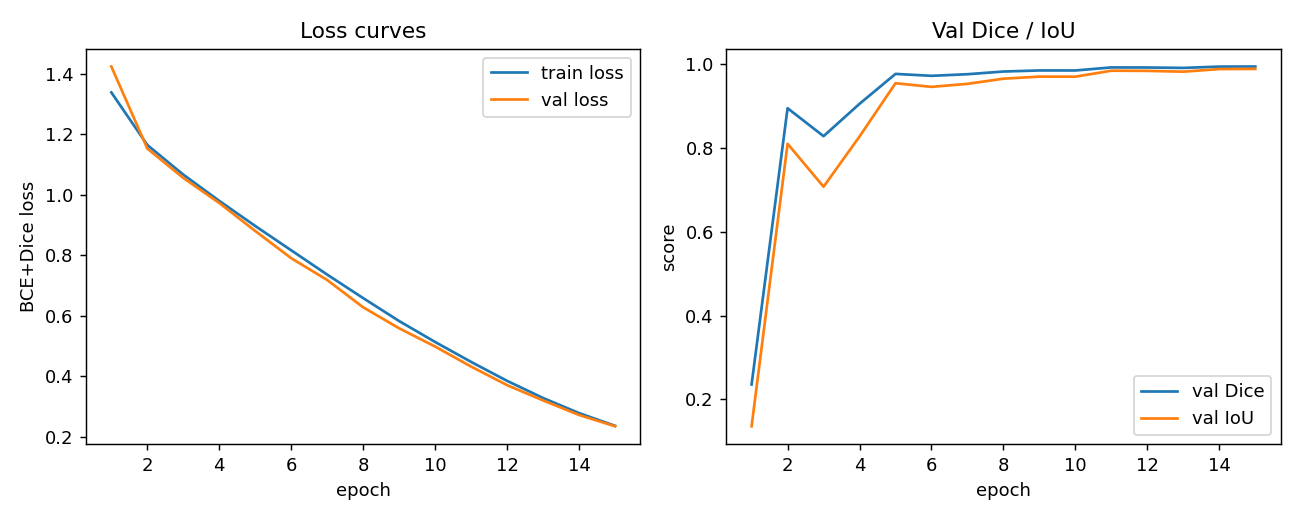

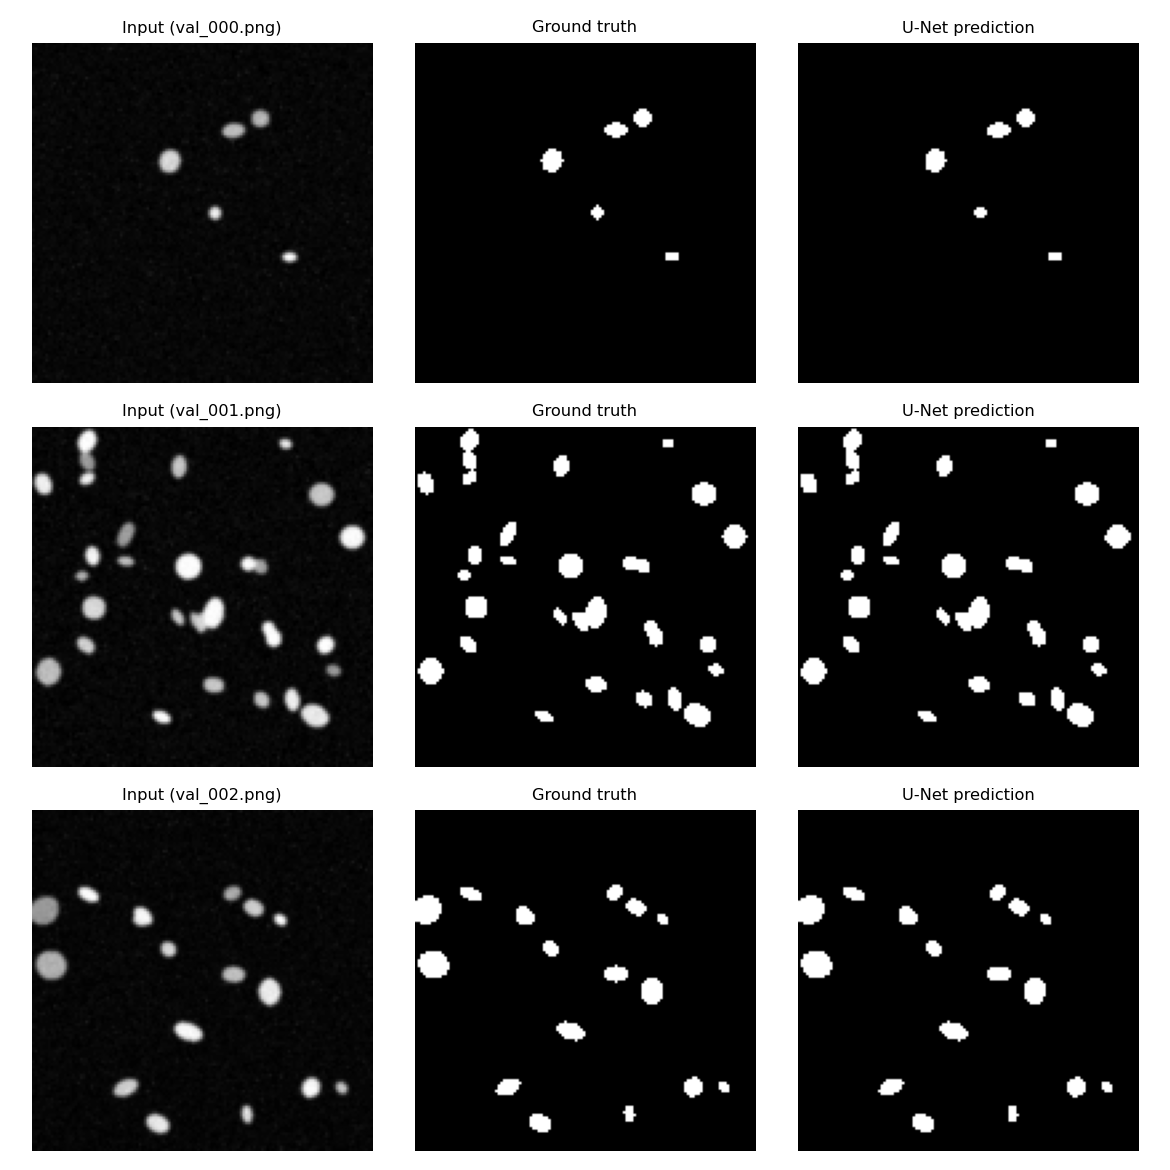

In [16]:
from IPython.display import Image as IPImage, display
display(IPImage(filename="outputs/task3_loss_dice_curves.png"))
display(IPImage(filename="outputs/task3_val_panels.png"))


### U-Net vs. classical Otsu on the held-out TEST split
Same 12 test images and ground-truth masks, comparing the trained U-Net against Otsu + morphology.


In [17]:
"""Evaluate trained U-Net on the held-out TEST split, and compare against
Otsu+morphology on the same images/masks -> answers report Q2 & Q3."""
import glob, os
import numpy as np
import pandas as pd
from PIL import Image
import torch
from skimage.filters import threshold_otsu
from skimage.morphology import opening, closing, disk, remove_small_objects
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# from task3_unet import SmallUNet, dice_iou, DEVICE  (already defined above in this notebook)

OUT = "outputs"
DATA_DIR = "nuclei_dataset"
IMG_SIZE = 128

def load_gray(path, size=IMG_SIZE):
    return np.array(Image.open(path).convert("L").resize((size,size), Image.BILINEAR), dtype=np.float32)/255.0

def load_mask(path, size=IMG_SIZE):
    return (np.array(Image.open(path).convert("L").resize((size,size), Image.NEAREST)) > 127).astype(np.float32)

def otsu_binary(gray):
    t = threshold_otsu(gray)
    b = gray > t
    b = opening(b, disk(1))
    b = closing(b, disk(1))
    b = remove_small_objects(b, min_size=8)
    return b.astype(np.float32)

def dice_np(a, b, eps=1e-6):
    inter = (a*b).sum()
    return (2*inter+eps)/(a.sum()+b.sum()+eps)

def iou_np(a, b, eps=1e-6):
    inter = (a*b).sum()
    union = a.sum()+b.sum()-inter
    return (inter+eps)/(union+eps)

model = SmallUNet(base=16).to(DEVICE)
model.load_state_dict(torch.load(f"{OUT}/unet_state_dict.pt", map_location=DEVICE))
model.eval()

img_paths = sorted(glob.glob(f"{DATA_DIR}/test/images/*.png"))
mask_paths = sorted(glob.glob(f"{DATA_DIR}/test/masks/*.png"))

rows = []
worst_unet, best_otsu_vs_unet = None, None
for ip, mp in zip(img_paths, mask_paths):
    image_id = os.path.splitext(os.path.basename(ip))[0]
    gray = load_gray(ip)
    gt = load_mask(mp)

    with torch.no_grad():
        t = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).to(DEVICE)
        logits = model(t)
        pred = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze().numpy()

    otsu_pred = otsu_binary(gray)

    d_unet, i_unet = dice_np(pred, gt), iou_np(pred, gt)
    d_otsu, i_otsu = dice_np(otsu_pred, gt), iou_np(otsu_pred, gt)
    rows.append({"image_id": image_id, "unet_dice": d_unet, "unet_iou": i_unet,
                 "otsu_dice": d_otsu, "otsu_iou": i_otsu})

df = pd.DataFrame(rows)
df.to_csv(f"{OUT}/task3_test_unet_vs_otsu.csv", index=False)
print(df.round(4))
print("\nMean U-Net  Dice/IoU:", df.unet_dice.mean().round(4), df.unet_iou.mean().round(4))
print("Mean Otsu   Dice/IoU:", df.otsu_dice.mean().round(4), df.otsu_iou.mean().round(4))

# find one image where U-Net beats Otsu by the largest margin, and vice versa
df["unet_minus_otsu"] = df["unet_dice"] - df["otsu_dice"]
best_for_unet = df.loc[df["unet_minus_otsu"].idxmax()]
best_for_otsu = df.loc[df["unet_minus_otsu"].idxmin()]
print("\nImage where U-Net wins most:", best_for_unet.image_id, "diff", round(best_for_unet.unet_minus_otsu,4))
print("Image where Otsu wins most (or U-Net worst relative):", best_for_otsu.image_id, "diff", round(best_for_otsu.unet_minus_otsu,4))

# visualize the two extreme examples: gt vs unet vs otsu
fig, axes = plt.subplots(2, 3, figsize=(9,6))
for row, image_id in enumerate([best_for_unet.image_id, best_for_otsu.image_id]):
    ip = f"{DATA_DIR}/test/images/{image_id}.png"
    mp = f"{DATA_DIR}/test/masks/{image_id}.png"
    gray = load_gray(ip); gt = load_mask(mp)
    with torch.no_grad():
        t = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).to(DEVICE)
        pred = (torch.sigmoid(model(t)) > 0.5).float().cpu().squeeze().numpy()
    otsu_pred = otsu_binary(gray)
    axes[row,0].imshow(gt, cmap="gray"); axes[row,0].set_title(f"{image_id} GT"); axes[row,0].axis("off")
    axes[row,1].imshow(pred, cmap="gray"); axes[row,1].set_title("U-Net"); axes[row,1].axis("off")
    axes[row,2].imshow(otsu_pred, cmap="gray"); axes[row,2].set_title("Otsu"); axes[row,2].axis("off")
plt.tight_layout()
plt.savefig(f"{OUT}/task3_unet_vs_otsu_examples.png", dpi=130)
plt.close()
print("Saved outputs/task3_unet_vs_otsu_examples.png")


    image_id  unet_dice  unet_iou  otsu_dice  otsu_iou
0   test_000     0.9987    0.9973     0.9394    0.8856
1   test_001     0.9957    0.9914     0.9196    0.8512
2   test_002     0.9947    0.9895     0.9275    0.8648
3   test_003     0.9954    0.9908     0.9325    0.8736
4   test_004     0.9926    0.9854     0.9445    0.8948
5   test_005     0.9926    0.9854     0.9447    0.8952
6   test_006     0.9962    0.9925     0.9472    0.8998
7   test_007     0.9944    0.9889     0.9422    0.8907
8   test_008     0.9964    0.9928     0.9490    0.9030
9   test_009     0.9963    0.9926     0.9379    0.8831
10  test_010     0.9936    0.9873     0.9384    0.8839
11  test_011     0.9940    0.9881     0.9382    0.8837

Mean U-Net  Dice/IoU: 0.9951 0.9902
Mean Otsu   Dice/IoU: 0.9384 0.8841

Image where U-Net wins most: test_001 diff 0.0761
Image where Otsu wins most (or U-Net worst relative): test_008 diff 0.0474
Saved outputs/task3_unet_vs_otsu_examples.png


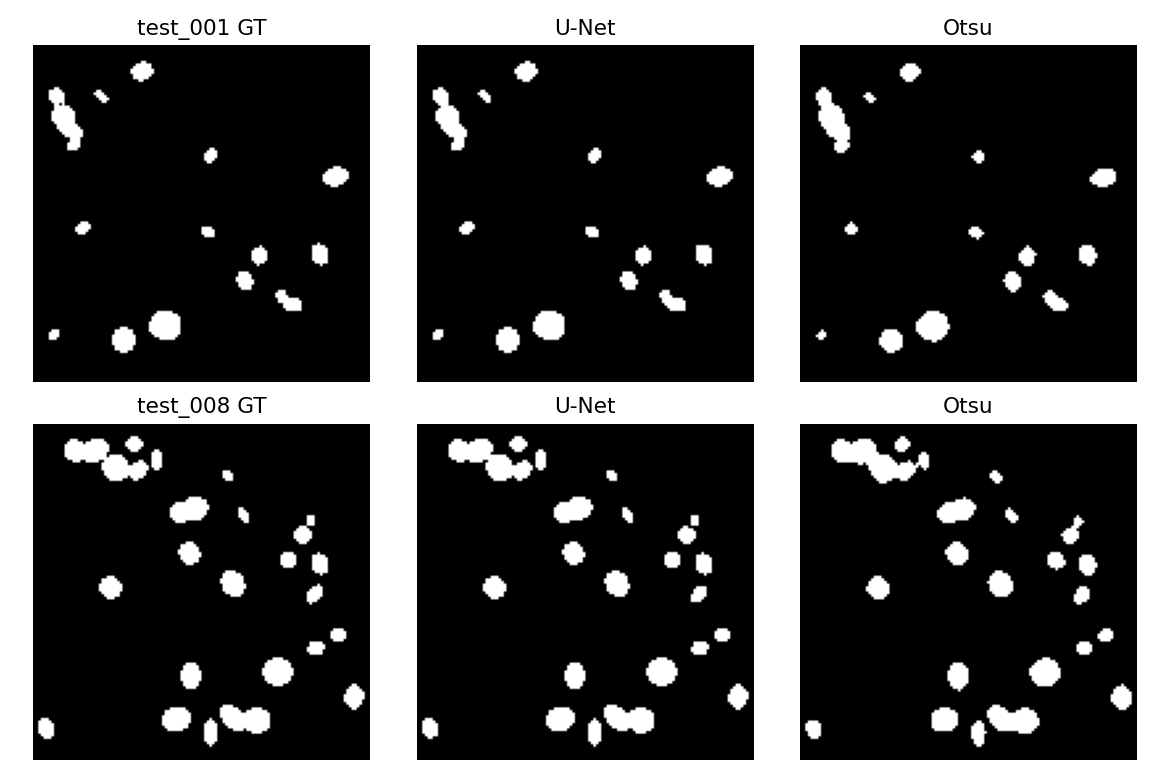

In [18]:
from IPython.display import Image as IPImage, display
display(IPImage(filename="outputs/task3_unet_vs_otsu_examples.png"))


## Task 4 — Hybrid pipeline on unseen test images

For every test image: U-Net mask → `regionprops` feature table → LLM structured JSON record
(`image_id`, `n_objects`, `mean_area`, `density_class`, `quality_flag`) → one-paragraph narrative.
`density_class` is computed deterministically from the measurements first (the "source of truth"); the LLM is
asked to phrase/flag it, not invent it — this is the main hallucination-mitigation design choice for this stage.
All records are aggregated into a DataFrame and saved as `outputs/task4_hybrid_records.csv`.


In [19]:
"""
Task 4: full hybrid pipeline on the unseen TEST images.
  U-Net mask -> regionprops feature table -> LLM structured JSON record -> narrative
Aggregates all records into outputs/task4_hybrid_records.csv

Non-LLM steps (U-Net inference, regionprops) run everywhere.
The LLM step is guarded: if Ollama isn't reachable, quality_flag records that,
and n_objects/mean_area/density_class are still filled in from the real features
so the CSV stays usable even before you run this with Ollama on.
"""
import os, glob, json
import numpy as np
import pandas as pd
from PIL import Image
import torch

# from task3_unet import SmallUNet, DEVICE  (already defined above in this notebook)
from skimage.measure import label, regionprops_table

try:
    import ollama
    OLLAMA_MODEL = "llama3.2"
    OLLAMA_AVAILABLE = True
except ImportError:
    OLLAMA_AVAILABLE = False

DATA_DIR = "nuclei_dataset"
OUT = "outputs"
IMG_SIZE = 128


def load_gray(path, size=IMG_SIZE):
    return np.array(Image.open(path).convert("L").resize((size, size), Image.BILINEAR), dtype=np.float32) / 255.0


def unet_mask(model, gray):
    with torch.no_grad():
        t = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).to(DEVICE)
        pred = (torch.sigmoid(model(t)) > 0.5).float().cpu().squeeze().numpy()
    return pred


def density_class_from_count(n, area_fraction):
    # simple, transparent rule mirroring the dataset's own regime definitions;
    # this is the "source of truth" the LLM's density_class should agree with
    if n < 15:
        return "sparse"
    elif n < 30:
        return "normal"
    elif area_fraction > 0.12 and n >= 30:
        return "dense"
    else:
        return "normal"


def build_llm_record(image_id, n_objects, mean_area, density_class):
    prompt = f"""You are given verified measurements from an automated image-analysis pipeline
(U-Net segmentation -> connected components -> regionprops). Do not contradict these numbers;
your job is only to phrase them and flag quality concerns.

image_id: {image_id}
n_objects: {n_objects}
mean_area_px2: {mean_area:.1f}
density_class (already computed, treat as ground truth): {density_class}

Return ONLY a JSON object:
{{
  "image_id": "{image_id}",
  "n_objects": {n_objects},
  "mean_area": {mean_area:.1f},
  "density_class": "{density_class}",
  "quality_flag": string   // "reliable", "check_segmentation", or "uncertain"
}}
Then on a new line write one short narrative sentence describing this image for a lab notebook."""
    response = ollama.chat(model=OLLAMA_MODEL, messages=[{"role": "user", "content": prompt}])
    return response["message"]["content"]


if True:
    model = SmallUNet(base=16).to(DEVICE)
    model.load_state_dict(torch.load(f"{OUT}/unet_state_dict.pt", map_location=DEVICE))
    model.eval()

    img_paths = sorted(glob.glob(f"{DATA_DIR}/test/images/*.png"))
    records = []

    for ip in img_paths:
        image_id = os.path.splitext(os.path.basename(ip))[0]
        gray = load_gray(ip)
        mask = unet_mask(model, gray)

        labeled = label(mask.astype(int))
        props = regionprops_table(labeled, properties=("label", "area"))
        n_objects = len(props["label"]) if len(props["label"]) else 0
        mean_area = float(np.mean(props["area"])) if n_objects else 0.0
        area_fraction = mask.sum() / mask.size
        dclass = density_class_from_count(n_objects, area_fraction)

        record = {
            "image_id": image_id, "n_objects": n_objects, "mean_area": round(mean_area, 1),
            "density_class": dclass, "quality_flag": "uncertain (LLM not run)",
            "narrative": "",
        }

        if OLLAMA_AVAILABLE:
            try:
                llm_text = build_llm_record(image_id, n_objects, mean_area, dclass)
                record["llm_raw_output"] = llm_text
                # best-effort parse: keep the raw text either way for auditability
                if "quality_flag" in llm_text:
                    for flag in ("reliable", "check_segmentation", "uncertain"):
                        if f'"{flag}"' in llm_text:
                            record["quality_flag"] = flag
                            break
            except Exception as e:
                record["llm_raw_output"] = f"Ollama call failed: {e}"

        records.append(record)
        print(record)

    df = pd.DataFrame(records)
    df.to_csv(f"{OUT}/task4_hybrid_records.csv", index=False)
    print(f"\nSaved {len(df)} records to outputs/task4_hybrid_records.csv")
    if not OLLAMA_AVAILABLE:
        print("\n(ollama package not importable in this environment)")


{'image_id': 'test_000', 'n_objects': 8, 'mean_area': 47.0, 'density_class': 'sparse', 'quality_flag': 'reliable', 'narrative': '', 'llm_raw_output': '{\n  "image_id": "test_000",\n  "n_objects": 8,\n  "mean_area": 47.0,\n  "density_class": "sparse",\n  "quality_flag": "reliable"\n}\n\nThis image appears to contain 8 distinct objects with relatively uniform areas, suggesting a sparse density class.'}
{'image_id': 'test_001', 'n_objects': 14, 'mean_area': 49.6, 'density_class': 'sparse', 'quality_flag': 'reliable', 'narrative': '', 'llm_raw_output': '{\n  "image_id": "test_001",\n  "n_objects": 14,\n  "mean_area": 49.6,\n  "density_class": "sparse",\n  "quality_flag": "reliable"\n}\n\nThis image contains 14 well-defined regions, with a mean area of approximately 50 square pixels, indicating a sparse and relatively uniform distribution.'}
{'image_id': 'test_002', 'n_objects': 25, 'mean_area': 56.7, 'density_class': 'normal', 'quality_flag': 'reliable', 'narrative': '', 'llm_raw_output': 

In [20]:
import pandas as pd
pd.read_csv("outputs/task4_hybrid_records.csv")


,image_id,n_objects,mean_area,density_class,quality_flag,narrative,llm_raw_output
0,test_000,8,47.0,sparse,reliable,NaN,"{\n ""image_id"": ""test_000"",\n ""n_objects"": 8..."
1,test_001,14,49.6,sparse,reliable,NaN,"{\n ""image_id"": ""test_001"",\n ""n_objects"": 1..."
2,test_002,25,56.7,normal,reliable,NaN,"{\n ""image_id"": ""test_002"",\n ""n_objects"": 2..."
3,test_003,19,51.7,normal,reliable,NaN,"{\n ""image_id"": ""test_003"",\n ""n_objects"": 1..."
4,test_004,43,81.9,dense,reliable,NaN,"{\n ""image_id"": ""test_004"",\n ""n_objects"": 4..."
5,test_005,15,108.1,normal,reliable,NaN,"{\n ""image_id"": ""test_005"",\n ""n_objects"": 1..."
6,test_006,8,50.0,sparse,reliable,NaN,"{\n ""image_id"": ""test_006"",\n ""n_objects"": 8..."
7,test_007,23,50.4,normal,reliable,NaN,"{\n ""image_id"": ""test_007"",\n ""n_objects"": 2..."
8,test_008,23,60.2,normal,reliable,NaN,"{\n ""image_id"": ""test_008"",\n ""n_objects"": 2..."
9,test_009,21,44.9,normal,reliable,NaN,"{\n ""image_id"": ""test_009"",\n ""n_objects"": 2..."


## Extension — Robustness (extra credit)

`test_000` is compared against its pre-supplied `blur` and `low_contrast` corrupted variants
(from `test_corrupted/`). Corruption is traced through the U-Net mask and the resulting feature counts,
to identify the earliest pipeline stage at which it becomes detectable.


In [21]:
"""
Extra-credit extension: robustness. Trace test_000 (clean) vs its blurred and
low-contrast variants through: U-Net mask -> feature table -> (would-be LLM
narrative) and find the earliest stage the corruption becomes visible/detectable.
"""
import numpy as np
import pandas as pd
from PIL import Image
import torch
from skimage.measure import label, regionprops_table
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# from task3_unet import SmallUNet, DEVICE  (already defined above in this notebook)

OUT = "outputs"
DATA_DIR = "nuclei_dataset"
IMG_SIZE = 128

def load_gray(path, size=IMG_SIZE):
    return np.array(Image.open(path).convert("L").resize((size, size), Image.BILINEAR), dtype=np.float32) / 255.0

model = SmallUNet(base=16).to(DEVICE)
model.load_state_dict(torch.load(f"{OUT}/unet_state_dict.pt", map_location=DEVICE))
model.eval()

variants = {
    "clean": f"{DATA_DIR}/test/images/test_000.png",
    "blur": f"{DATA_DIR}/test_corrupted/images/test_000_blur.png",
    "low_contrast": f"{DATA_DIR}/test_corrupted/images/test_000_lowcontrast.png",
}

rows = []
fig, axes = plt.subplots(2, 3, figsize=(9,6))
for col, (name, path) in enumerate(variants.items()):
    gray = load_gray(path)
    with torch.no_grad():
        t = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).to(DEVICE)
        pred = (torch.sigmoid(model(t)) > 0.5).float().cpu().squeeze().numpy()
    labeled = label(pred.astype(int))
    props = regionprops_table(labeled, properties=("label", "area"))
    n = len(props["label"])
    mean_area = float(np.mean(props["area"])) if n else 0.0
    rows.append({"variant": name, "n_objects": n, "mean_area": round(mean_area,1)})

    axes[0, col].imshow(gray, cmap="gray"); axes[0, col].set_title(f"{name} input"); axes[0, col].axis("off")
    axes[1, col].imshow(pred, cmap="gray"); axes[1, col].set_title(f"{name} U-Net mask"); axes[1, col].axis("off")

plt.tight_layout()
plt.savefig(f"{OUT}/extension_robustness_panels.png", dpi=130)
plt.close()

df = pd.DataFrame(rows)
df.to_csv(f"{OUT}/extension_robustness_table.csv", index=False)
print(df)
print("\nSaved outputs/extension_robustness_panels.png")


        variant  n_objects  mean_area
0         clean          8       47.0
1          blur          7       86.7
2  low_contrast          1    16383.0

Saved outputs/extension_robustness_panels.png


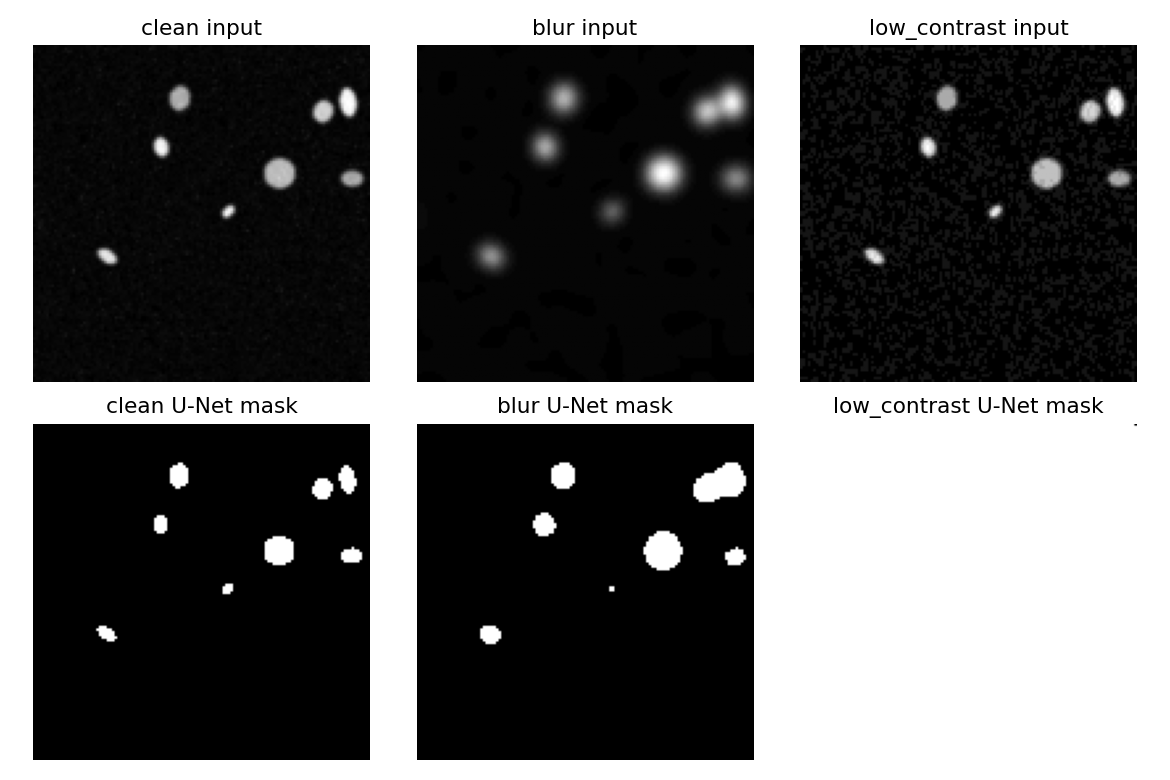

In [22]:
from IPython.display import Image as IPImage, display
display(IPImage(filename="outputs/extension_robustness_panels.png"))


**Observation:** the low-contrast variant adds background speckle noise across the whole frame; the U-Net —
never trained on this noise pattern — over-segments almost the entire image into foreground at the **mask stage
itself**, before any feature extraction or LLM step runs. The blur variant degrades more gracefully (object count
drops from 8→7, but shapes stay roughly correct). This means the earliest reliably-detectable stage for a
contrast-type corruption is the segmentation mask, not the downstream feature table or narrative — a mask-level
sanity check (e.g. flag if predicted foreground area fraction is an outlier vs. the training distribution) would
catch this before it propagates into a JSON record.


## Download your results from Colab

Colab's filesystem is temporary — download the trained model and CSVs before your session ends,
or save them straight to Google Drive.


In [23]:
# Option A: download directly to your laptop
from google.colab import files
files.download("outputs/unet_state_dict.pt")
files.download("outputs/task4_hybrid_records.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# Option B: save everything to Google Drive instead
# from google.colab import drive
# drive.mount('/content/drive')
# !cp -r outputs /content/drive/MyDrive/biomedical_pipeline_outputs
